In [4]:
#installing tensorflow version 2.0
# %pip install tensorflow

In [5]:
#importing all the required libraries
import pandas as pd  ## for data manipulation
import matplotlib.pyplot as plt   ## for making graphs and statistical analysis
import numpy as np  ## for mathematical operation
import seaborn as sns ##

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam  ## used for weight update and improves gradient descent
from tensorflow.keras.metrics import Accuracy

from sklearn import metrics   ## usef for  measure model performance 
from sklearn.preprocessing import LabelEncoder  ## text ko number me convert krta hai basically used in EDA part  
from sklearn.metrics import classification_report,accuracy_score,roc_curve,confusion_matrix  ## detialed report bnata hai on the basis of confusion matrix

## -Loading our instagram dataset

In [6]:
# test or training data laod 
import pandas as pd
ig_df_test = pd.read_csv('instagram_test.csv')
ig_df_train = pd.read_csv('instagram_train.csv')

In [7]:
## dataset for training the model
ig_df_train

,pos,flw,flg,bl,pic,lin,cl,cz,ni,erl,erc,lt,hc,pr,fo,cs,pi,class
0,4,39,62,45,1,0,23,0.500000,0.000,74.360001,6.41,0.000,0.000,0.000,0.000,0.166667,6.106042,r
1,18,38,168,0,1,0,88,0.166667,0.000,15.060000,0.15,0.056,1.000,0.000,0.000,0.028581,76.119148,f
2,206,1100,1200,96,1,0,259,0.000000,0.500,11.650000,0.49,0.611,0.556,0.000,0.111,0.103029,150.867294,r
3,9,305,7000,0,1,0,2,0.777778,0.000,160.770004,0.98,0.000,0.000,0.000,0.000,0.583333,156.063110,f
4,10,56,65,111,1,1,610,0.100000,0.000,6.070000,0.71,0.600,1.400,0.000,0.000,0.800000,11.995028,r
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52255,148,1300,3500,0,1,0,269,0.055556,0.056,2.850000,0.38,0.389,0.278,0.000,0.000,0.060459,164.180176,f
52256,246,1500,3900,51,1,0,546,0.000000,0.444,0.840000,0.13,0.222,0.778,1.056,0.000,0.138151,100.806419,f
52257,360,1300,1300,0,1,0,40,0.000000,0.778,17.100000,0.50,0.833,0.111,0.000,0.056,0.024588,580.220764,r
52258,111,1200,3200,22,1,1,38,0.166667,0.500,4.390000,0.11,0.111,0.389,0.000,0.000,0.144190,556.404846,f


In [8]:
## dataset for testing the model
ig_df_test

,pos,flw,flg,bl,pic,lin,cl,cz,ni,erl,erc,lt,hc,pr,fo,cs,pi,class
0,122,1000,2600,0,1,0,11,0.500000,0.778,2.670000,0.08,0.389,0.000,0.0,0.000,0.183007,609.477051,f
1,5,1300,942,52,1,0,98,0.000000,0.200,17.280001,0.86,0.000,0.200,0.0,0.000,0.051288,1910.938110,r
2,18,101,20,159,1,1,322,0.000000,0.556,15.130000,0.66,0.111,0.000,0.0,0.000,0.045038,568.422302,r
3,11,135,1400,0,1,0,41,0.090909,0.000,48.959999,2.83,0.000,1.364,0.0,0.000,0.058609,54.100933,f
4,36,537,972,114,1,1,4,0.666667,0.000,10.390000,0.03,0.833,0.000,0.0,0.000,0.529412,43.746174,r
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13061,1100,2000,3800,128,1,1,525,0.000000,0.333,0.410000,0.00,0.944,1.722,0.0,0.000,0.538592,9.144861,r
13062,102,1200,611,30,1,0,202,0.000000,0.778,8.790000,0.54,0.611,0.167,0.0,0.000,0.031719,233.404221,r
13063,3,63,437,130,1,0,14,0.333333,0.000,20.110001,2.12,0.000,0.000,0.0,0.000,0.000000,1.845093,f
13064,151,196,852,343,1,0,48,0.222222,0.222,22.790001,1.56,0.389,0.833,0.0,0.056,0.041621,1271.359497,r


### **<h3>Performing EDA(Exploratory Data Analysisi)**

*   **<h3><i>Performing Exploratory Data Anlaysis For "Training Dataset"**

In [9]:
ig_df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52260 entries, 0 to 52259
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pos     52260 non-null  int64  
 1   flw     52260 non-null  int64  
 2   flg     52260 non-null  int64  
 3   bl      52260 non-null  int64  
 4   pic     52260 non-null  int64  
 5   lin     52260 non-null  int64  
 6   cl      52260 non-null  int64  
 7   cz      52260 non-null  float64
 8   ni      52260 non-null  float64
 9   erl     52260 non-null  float64
 10  erc     52260 non-null  float64
 11  lt      52260 non-null  float64
 12  hc      52260 non-null  float64
 13  pr      52260 non-null  float64
 14  fo      52260 non-null  float64
 15  cs      52260 non-null  float64
 16  pi      52260 non-null  float64
 17  class   52260 non-null  object 
dtypes: float64(10), int64(7), object(1)
memory usage: 7.2+ MB


In [10]:
ig_df_train.drop(columns=["fo"], inplace=True)

In [11]:
import numpy as np
ig_df_train['class']=np.where(ig_df_train['class'].str.contains("r"),0,1)

In [12]:
ig_df_test['class']=np.where(ig_df_test['class'].str.contains("r"),0,1)

In [13]:
ig_df_train.head()

,pos,flw,flg,bl,pic,lin,cl,cz,ni,erl,erc,lt,hc,pr,cs,pi,class
0,4,39,62,45,1,0,23,0.500000,0.0,74.360001,6.41,0.000,0.000,0.0,0.166667,6.106042,0
1,18,38,168,0,1,0,88,0.166667,0.0,15.060000,0.15,0.056,1.000,0.0,0.028581,76.119148,1
2,206,1100,1200,96,1,0,259,0.000000,0.5,11.650000,0.49,0.611,0.556,0.0,0.103029,150.867294,0
3,9,305,7000,0,1,0,2,0.777778,0.0,160.770004,0.98,0.000,0.000,0.0,0.583333,156.063110,1
4,10,56,65,111,1,1,610,0.100000,0.0,6.070000,0.71,0.600,1.400,0.0,0.800000,11.995028,0


In [14]:
ig_df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52260 entries, 0 to 52259
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pos     52260 non-null  int64  
 1   flw     52260 non-null  int64  
 2   flg     52260 non-null  int64  
 3   bl      52260 non-null  int64  
 4   pic     52260 non-null  int64  
 5   lin     52260 non-null  int64  
 6   cl      52260 non-null  int64  
 7   cz      52260 non-null  float64
 8   ni      52260 non-null  float64
 9   erl     52260 non-null  float64
 10  erc     52260 non-null  float64
 11  lt      52260 non-null  float64
 12  hc      52260 non-null  float64
 13  pr      52260 non-null  float64
 14  cs      52260 non-null  float64
 15  pi      52260 non-null  float64
 16  class   52260 non-null  int64  
dtypes: float64(9), int64(8)
memory usage: 6.8 MB


In [15]:
ig_df_train.duplicated().sum()

np.int64(800)

In [16]:
ig_df_train = ig_df_train.drop_duplicates()

In [17]:
ig_df_train.duplicated().sum()

np.int64(0)

In [18]:
ig_df_train.describe()

,pos,flw,flg,bl,pic,lin,cl,cz,ni,erl,erc,lt,hc,pr,cs,pi,class
count,51460.000000,5.146000e+04,51460.000000,51460.000000,51460.000000,51460.000000,51460.000000,51460.000000,51460.000000,51460.000000,51460.000000,51460.000000,51460.000000,51460.000000,51460.000000,51460.000000,51460.000000
mean,181.152274,1.219239e+03,2295.106393,58.376972,0.958706,0.286203,138.360532,0.253522,0.196279,19.638824,1.156702,0.212082,0.514350,0.032750,0.290230,501.908486,0.495375
std,770.881575,2.390271e+04,2573.455126,64.258605,0.198972,0.451990,216.761485,0.338905,0.253994,134.279737,6.103003,0.301527,1.129567,0.211541,0.342599,927.467595,0.499983
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,1.300000e+02,401.000000,0.000000,1.000000,0.000000,9.000000,0.000000,0.000000,3.010000,0.090000,0.000000,0.000000,0.000000,0.032556,28.425787,0.000000
50%,31.000000,3.475000e+02,995.000000,34.000000,1.000000,0.000000,48.000000,0.055556,0.083000,9.690000,0.460000,0.000000,0.111000,0.000000,0.133052,189.852806,0.000000
75%,126.000000,8.270000e+02,3500.000000,111.000000,1.000000,1.000000,174.000000,0.444444,0.333000,18.860001,1.060000,0.353000,0.611000,0.000000,0.431990,592.820938,1.000000
max,76200.000000,3.900000e+06,8800.000000,555.000000,1.000000,1.000000,3644.000000,1.000000,1.000000,26650.000000,1009.090027,1.000000,30.000000,20.000000,1.000000,25621.597656,1.000000


In [19]:
ig_df_train.isnull().sum()

pos      0
flw      0
flg      0
bl       0
pic      0
lin      0
cl       0
cz       0
ni       0
erl      0
erc      0
lt       0
hc       0
pr       0
cs       0
pi       0
class    0
dtype: int64

In [20]:
## number of unique values in the profile pic col
ig_df_train['pic'].value_counts()

pic
1    49335
0     2125
Name: count, dtype: int64

In [21]:
## 0 - real
## 1- fake`
ig_df_train['class'].value_counts()      

class
0    25968
1    25492
Name: count, dtype: int64

since training dataset is balance :
Model biased nahi hoga

Accuracy reliable hogi

Stratified split ka result stable hog - Model ko balanced data milega train aur test dono me

In [22]:
ig_df_test['class'].value_counts() 

class
1    6574
0    6492
Name: count, dtype: int64

In [23]:
#Number of accounts having an external URL
ig_df_train['lin'].value_counts()

lin
0    36732
1    14728
Name: count, dtype: int64

1 - link given

0 - no link 

mtlb bs 5% log hi external link add krte hai 

In [24]:
#Number of accounts having description length over 50
(ig_df_train['bl'] > 50).sum()

np.int64(22247)

*   **<h3><i>Performing Exploratory Data Anlaysis For "Testing Dataset"**

In [25]:
ig_df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13066 entries, 0 to 13065
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pos     13066 non-null  int64  
 1   flw     13066 non-null  int64  
 2   flg     13066 non-null  int64  
 3   bl      13066 non-null  int64  
 4   pic     13066 non-null  int64  
 5   lin     13066 non-null  int64  
 6   cl      13066 non-null  int64  
 7   cz      13066 non-null  float64
 8   ni      13066 non-null  float64
 9   erl     13066 non-null  float64
 10  erc     13066 non-null  float64
 11  lt      13066 non-null  float64
 12  hc      13066 non-null  float64
 13  pr      13066 non-null  float64
 14  fo      13066 non-null  float64
 15  cs      13066 non-null  float64
 16  pi      13066 non-null  float64
 17  class   13066 non-null  int64  
dtypes: float64(10), int64(8)
memory usage: 1.8 MB


In [26]:
ig_df_test.drop(columns=["fo"], inplace=True)

In [27]:
ig_df_test.duplicated().sum()

np.int64(107)

In [28]:
ig_df_test = ig_df_test.drop_duplicates()

In [29]:
ig_df_test.duplicated().sum()

np.int64(0)

In [30]:
ig_df_test.describe()

,pos,flw,flg,bl,pic,lin,cl,cz,ni,erl,erc,lt,hc,pr,cs,pi,class
count,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000,12959.000000
mean,170.738174,1120.431901,2329.864573,58.022378,0.956092,0.284667,138.780384,0.253341,0.194641,18.532259,1.150549,0.210771,0.517311,0.035014,0.297833,509.647948,0.499035
std,525.767770,10326.233105,2594.096840,64.033558,0.204898,0.451273,216.029473,0.338958,0.252359,47.279717,4.712147,0.301093,1.289311,0.261538,0.346985,1033.211892,0.500018
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,127.000000,405.000000,0.000000,1.000000,0.000000,8.000000,0.000000,0.000000,2.690000,0.080000,0.000000,0.000000,0.000000,0.035307,27.530416,0.000000
50%,30.000000,341.000000,1000.000000,33.000000,1.000000,0.000000,47.000000,0.055556,0.063000,9.480000,0.450000,0.000000,0.071000,0.000000,0.137255,185.712021,0.000000
75%,127.000000,835.000000,3700.000000,111.000000,1.000000,1.000000,173.000000,0.444444,0.333000,18.719999,1.040000,0.353000,0.611000,0.000000,0.450980,579.042633,1.000000
max,15300.000000,706500.000000,7700.000000,441.000000,1.000000,1.000000,3210.000000,1.000000,1.000000,1575.000000,344.130005,1.000000,30.000000,18.000000,1.000000,26786.134766,1.000000


In [31]:
ig_df_test.isnull().sum()

pos      0
flw      0
flg      0
bl       0
pic      0
lin      0
cl       0
cz       0
ni       0
erl      0
erc      0
lt       0
hc       0
pr       0
cs       0
pi       0
class    0
dtype: int64

In [32]:
ig_df_test['class'].value_counts()

class
0    6492
1    6467
Name: count, dtype: int64

**<h2>DATA VISUALIZATION**

## for training data

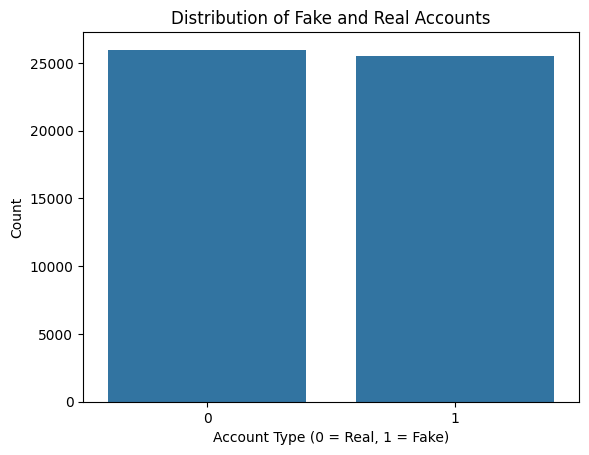

In [33]:
##visualize no of fake and real accounts
sns.countplot(data=ig_df_train, x='class')
plt.title("Distribution of Fake and Real Accounts")
plt.xlabel("Account Type (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.show()

In [73]:
##visualization of private(1) or public(0)
# sns.countplot(data=ig_df_train, x='private', palette="PuBu")
# plt.show()

C:\Users\anujg\AppData\Local\Temp\ipykernel_18940\1412818458.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ig_df_train, x='pic', palette="Pastel2")


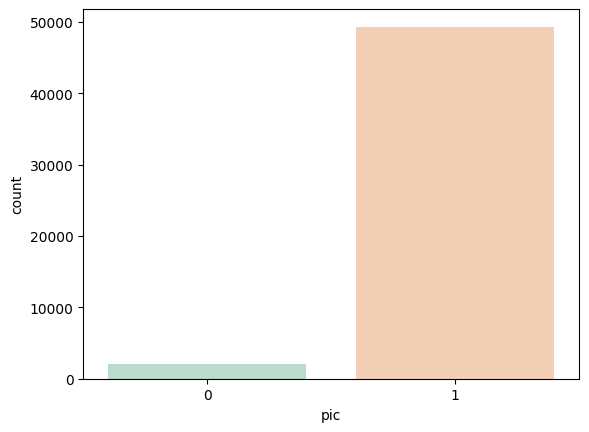

In [35]:
## visualize of how many profile has pic(1) or not(0)
sns.countplot(data=ig_df_train, x='pic', palette="Pastel2")
plt.show()

Text(0.5, 1.0, 'Distribution of Content Similarity')

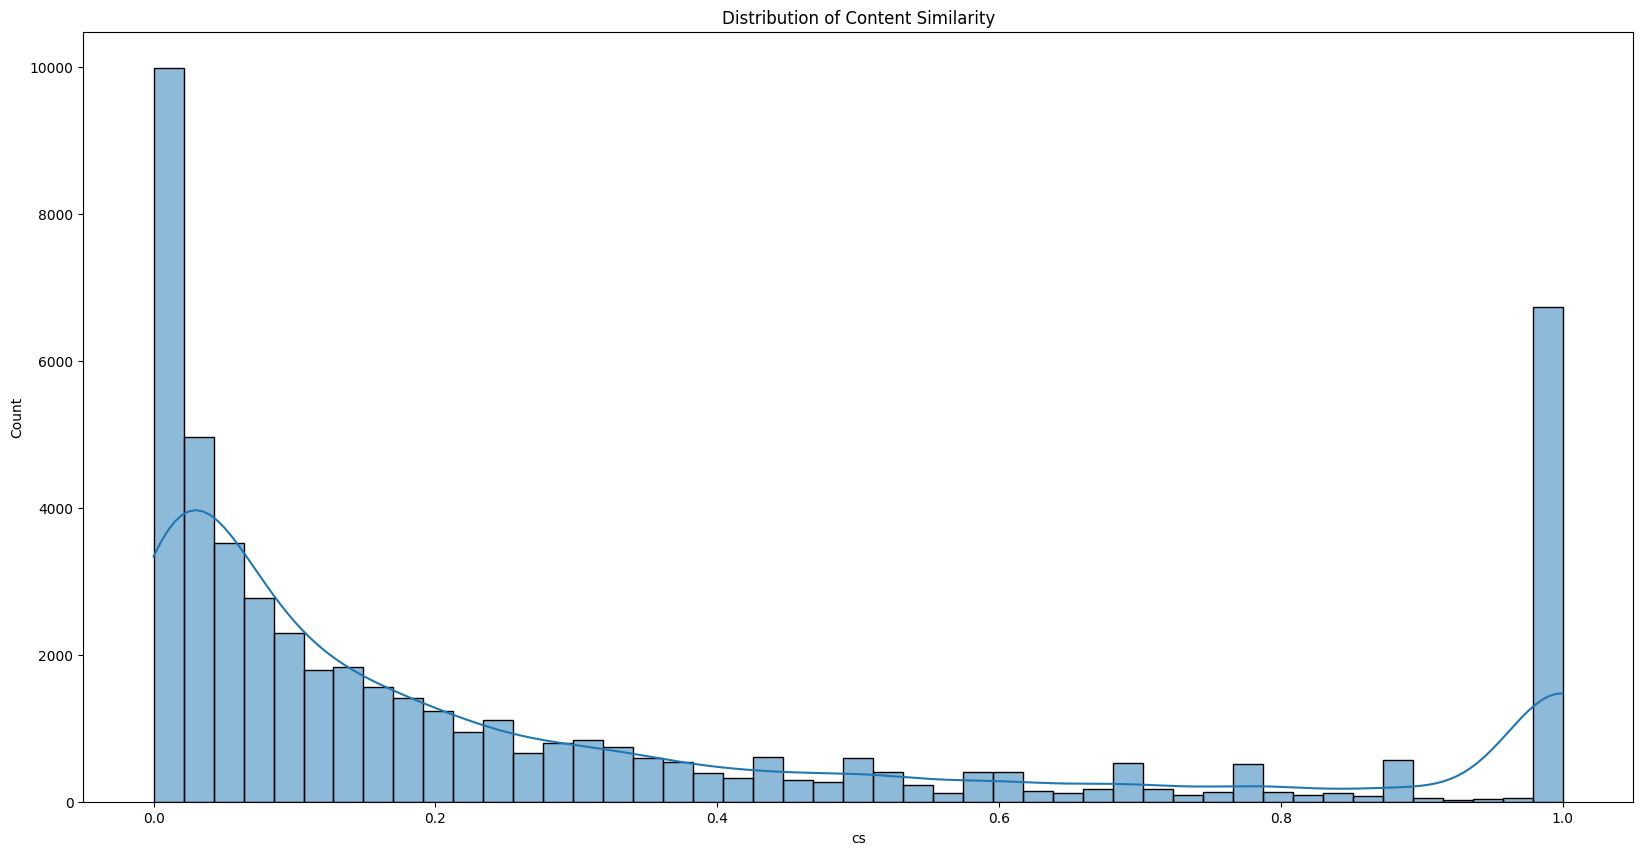

In [74]:
##content similarity distribution
plt.figure(figsize= (20, 10))
sns.histplot(ig_df_train['cs'],kde=True)
plt.title("Distribution of Content Similarity")

<Axes: >

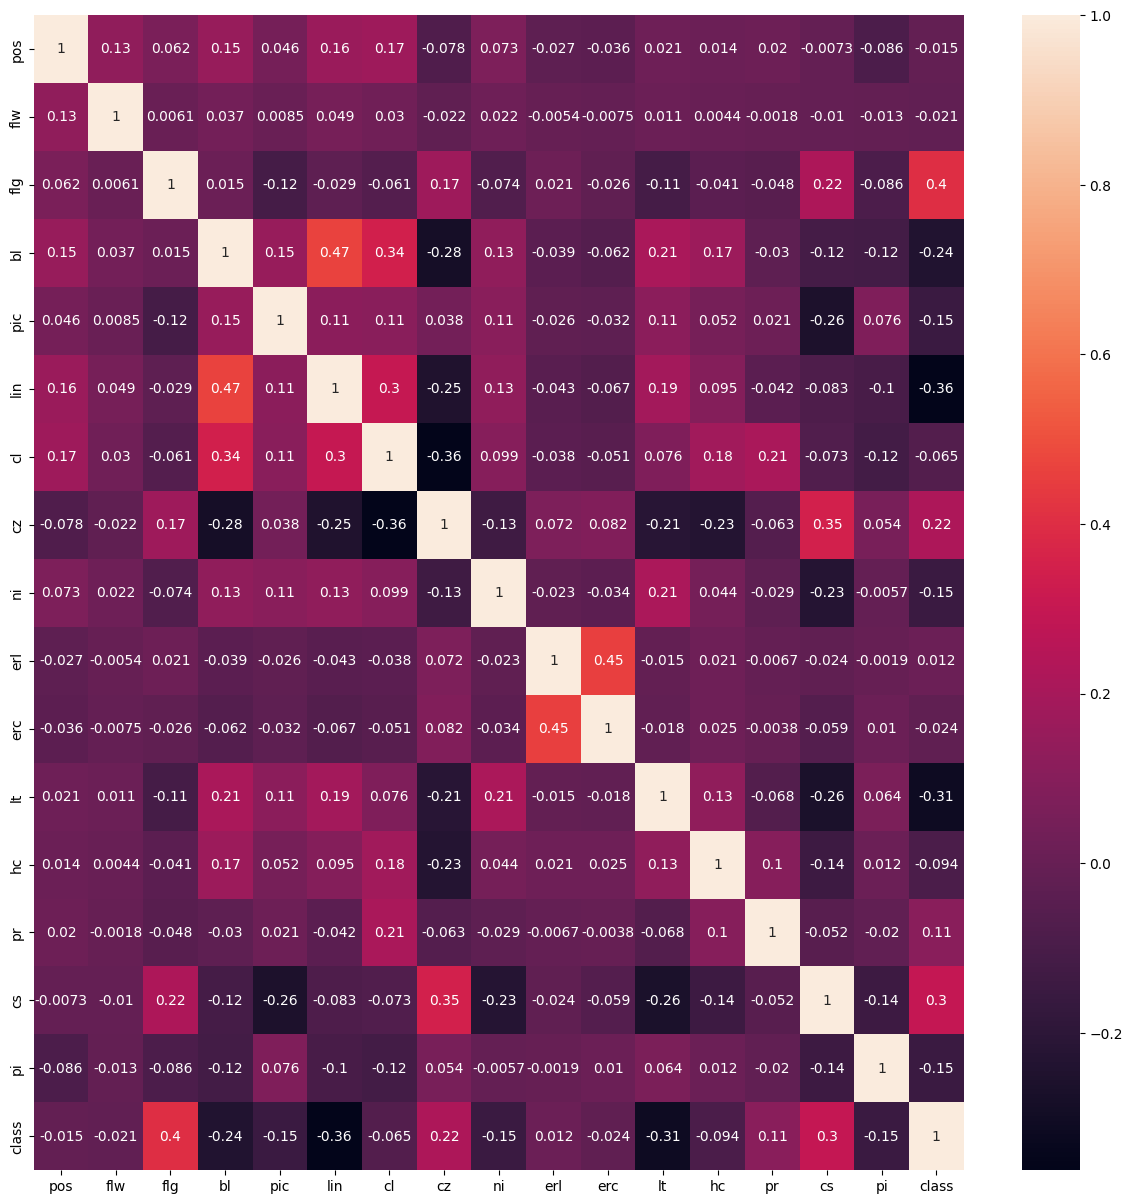

In [37]:
##correlation heatmap
plt.figure(figsize=(15,15))
cm = ig_df_train.corr()
ax = plt.subplot()
sns.heatmap(cm, annot= True, ax = ax)

## data visualization for testing data

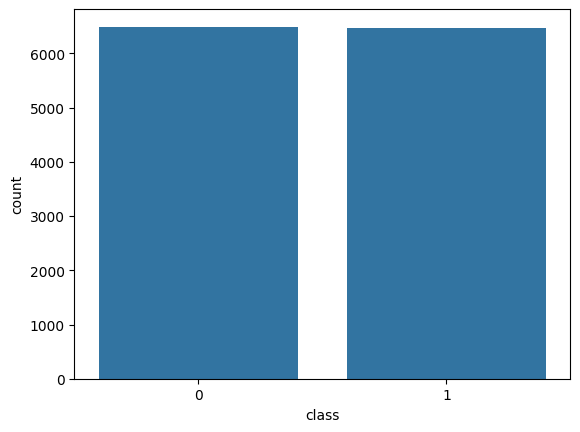

In [38]:
sns.countplot(data=ig_df_test, x='class')
plt.show()

In [39]:
##visualization of private(1) or public(0)
# sns.countplot(data=ig_df_test, x='private', palette="Set2")
# plt.show()

C:\Users\anujg\AppData\Local\Temp\ipykernel_18940\3637615870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ig_df_test, x='pic', palette="Pastel2")


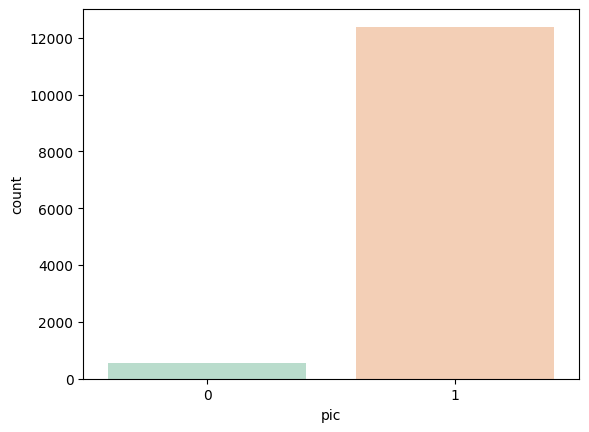

In [40]:
## visualize of how many profile has pic(1) or not(0)
sns.countplot(data=ig_df_test, x='pic', palette="Pastel2")
plt.show()

--
**<h2>PREPARING THE DATA TO FEED THE MODEL**

In [41]:
#Preparing inputs for the model -> Dropping the fake column from both training and testing dataset
x_train = ig_df_train.drop(columns = ['class'])
x_test = ig_df_test.drop(columns = ['class'])

In [42]:
x_train

,pos,flw,flg,bl,pic,lin,cl,cz,ni,erl,erc,lt,hc,pr,cs,pi
0,4,39,62,45,1,0,23,0.500000,0.000,74.360001,6.41,0.000,0.000,0.000,0.166667,6.106042
1,18,38,168,0,1,0,88,0.166667,0.000,15.060000,0.15,0.056,1.000,0.000,0.028581,76.119148
2,206,1100,1200,96,1,0,259,0.000000,0.500,11.650000,0.49,0.611,0.556,0.000,0.103029,150.867294
3,9,305,7000,0,1,0,2,0.777778,0.000,160.770004,0.98,0.000,0.000,0.000,0.583333,156.063110
4,10,56,65,111,1,1,610,0.100000,0.000,6.070000,0.71,0.600,1.400,0.000,0.800000,11.995028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52255,148,1300,3500,0,1,0,269,0.055556,0.056,2.850000,0.38,0.389,0.278,0.000,0.060459,164.180176
52256,246,1500,3900,51,1,0,546,0.000000,0.444,0.840000,0.13,0.222,0.778,1.056,0.138151,100.806419
52257,360,1300,1300,0,1,0,40,0.000000,0.778,17.100000,0.50,0.833,0.111,0.000,0.024588,580.220764
52258,111,1200,3200,22,1,1,38,0.166667,0.500,4.390000,0.11,0.111,0.389,0.000,0.144190,556.404846


In [43]:
x_test

,pos,flw,flg,bl,pic,lin,cl,cz,ni,erl,erc,lt,hc,pr,cs,pi
0,122,1000,2600,0,1,0,11,0.500000,0.778,2.670000,0.08,0.389,0.000,0.0,0.183007,609.477051
1,5,1300,942,52,1,0,98,0.000000,0.200,17.280001,0.86,0.000,0.200,0.0,0.051288,1910.938110
2,18,101,20,159,1,1,322,0.000000,0.556,15.130000,0.66,0.111,0.000,0.0,0.045038,568.422302
3,11,135,1400,0,1,0,41,0.090909,0.000,48.959999,2.83,0.000,1.364,0.0,0.058609,54.100933
4,36,537,972,114,1,1,4,0.666667,0.000,10.390000,0.03,0.833,0.000,0.0,0.529412,43.746174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13061,1100,2000,3800,128,1,1,525,0.000000,0.333,0.410000,0.00,0.944,1.722,0.0,0.538592,9.144861
13062,102,1200,611,30,1,0,202,0.000000,0.778,8.790000,0.54,0.611,0.167,0.0,0.031719,233.404221
13063,3,63,437,130,1,0,14,0.333333,0.000,20.110001,2.12,0.000,0.000,0.0,0.000000,1.845093
13064,151,196,852,343,1,0,48,0.222222,0.222,22.790001,1.56,0.389,0.833,0.0,0.041621,1271.359497


In [44]:
#Preparing the outputs -> Takin only the fake column into consideration.
y_train = ig_df_train['class']   ## model learn at the time of traning
y_test = ig_df_test['class']  ## testing data ka ouput hai used to check model accuracy

In [45]:
y_train

0        0
1        1
2        0
3        1
4        0
        ..
52255    1
52256    1
52257    0
52258    1
52259    1
Name: class, Length: 51460, dtype: int64

In [46]:
y_test

0        1
1        0
2        0
3        1
4        0
        ..
13061    0
13062    0
13063    1
13064    0
13065    1
Name: class, Length: 12959, dtype: int64

In [47]:
#Scaling the data before training the model (Normalize the data)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
##fit -> Training data ka mean aur standard deviation calculate karta hai. 
## transform -> fit() se nikale gye mean or SD ka use kr k z-score find krega
X_train = scaler.fit_transform(x_train)
## test data me only transfrom krte hai fit kran se data leakage ki problem hoga
X_test = scaler.transform(x_test)

In [48]:
Y_train = tf.keras.utils.to_categorical(y_train, num_classes=2)
Y_test = tf.keras.utils.to_categorical(y_test, num_classes=2)

In [49]:
X_train.shape,X_test.shape

((51460, 16), (12959, 16))

In [50]:
Y_train.shape,Y_test.shape

((51460, 2), (12959, 2))

In [51]:
#Percentage of Training data
Training_data_percentage = len(X_train)/(len(X_train) + len(X_test) ) * 100
Training_data_percentage

79.88326425433489

In [52]:
## percent of data used for testing
Testing_data_percentage = len(X_test)/(len(X_train) + len(X_test) ) * 100
Testing_data_percentage

20.1167357456651

## Logistic regression

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

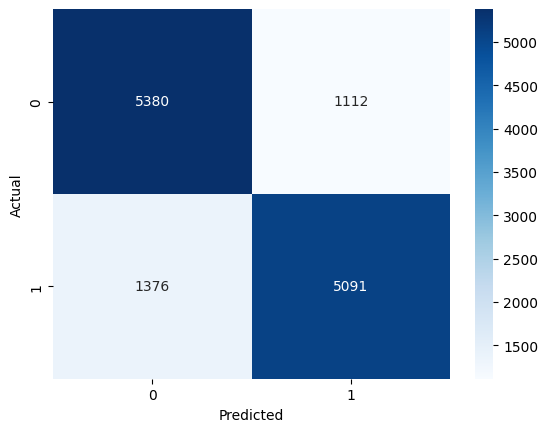

In [54]:
## confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [55]:
accuracy_score(y_test, y_pred)

0.8080098773053477

In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)  ## TP / (TP + FP)
print("Recall:", recall)        ##  TP / (TP + FN)
print("F1 Score:", f1)          ##   2 * (Precision * Recall) / (Precision + Recall)

Precision: 0.8207319039174593
Recall: 0.7872274625019329
F1 Score: 0.8036306235201263


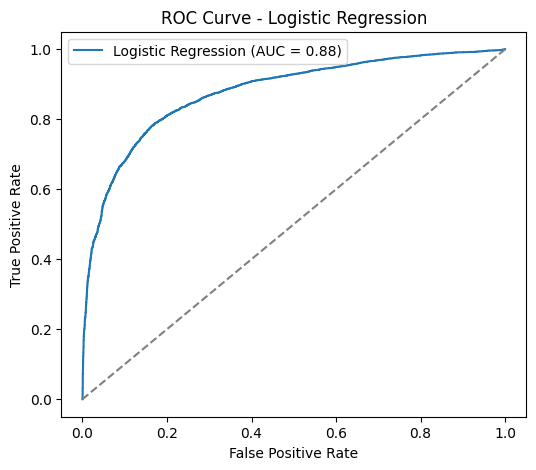

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

# calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

# plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression (AUC = {:.2f})".format(auc_score))
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

## Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

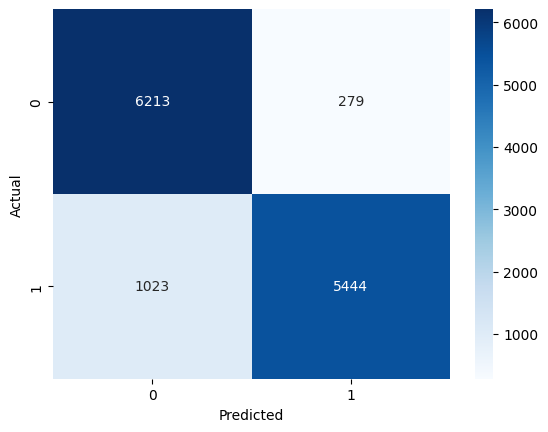

In [59]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
accuracy_score(y_test, y_pred_rf)

0.8995292846670268

In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print("Precision:", precision)  ## TP / (TP + FP)
print("Recall:", recall)        ##  TP / (TP + FN)
print("F1 Score:", f1)          ##   2 * (Precision * Recall) / (Precision + Recall)

Precision: 0.9512493447492574
Recall: 0.8418122777176434
F1 Score: 0.8931911402789171


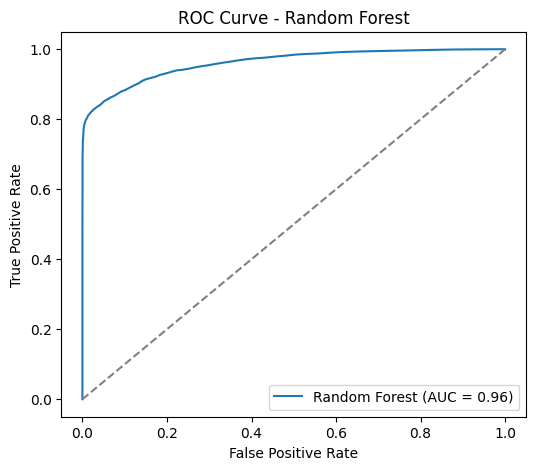

In [62]:
from sklearn.metrics import roc_curve, roc_auc_score

# probability prediction
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# AUC score
auc_rf = roc_auc_score(y_test, y_prob_rf)

# plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest (AUC = {:.2f})".format(auc_rf))
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

## LightBGM 

LightGBM (Light Gradient Boosting Machine) fake-account detection jaise tabular datasets me bahut powerful model hota hai. Ye Random Forest aur XGBoost se bhi fast aur accurate ho sakta hai.

In [63]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [64]:
import lightgbm as lgb
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    class_weight='balanced',
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)

[LightGBM] [Info] Number of positive: 25492, number of negative: 25968
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 51460, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\anujg\anaconda3\envs\IG\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [65]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lgb))

Accuracy: 0.9049309360290145


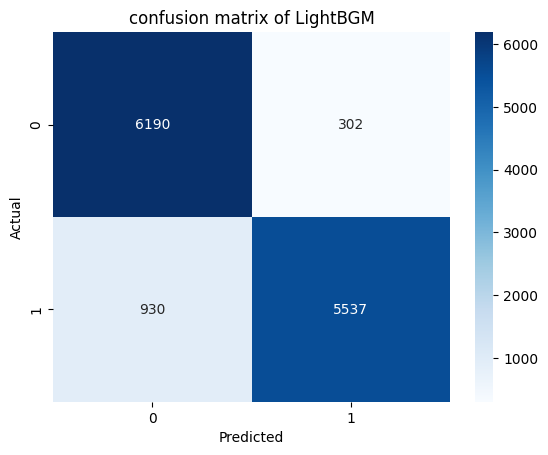

In [66]:
cm = confusion_matrix(y_test, y_pred_lgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion matrix of LightBGM")
plt.show()

In [67]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_lgb)
recall = recall_score(y_test, y_pred_lgb)
f1 = f1_score(y_test, y_pred_lgb)

print("Precision:", precision)  ## TP / (TP + FP)
print("Recall:", recall)        ##  TP / (TP + FN)
print("F1 Score:", f1)          ##   2 * (Precision * Recall) / (Precision + Recall)

Precision: 0.9482788148655592
Recall: 0.8561929797433122
F1 Score: 0.8998862343572241


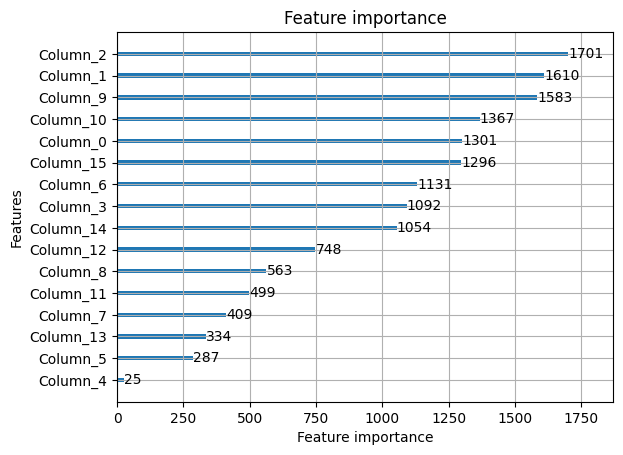

In [68]:
import matplotlib.pyplot as plt
import lightgbm as lgb

lgb.plot_importance(lgb_model)
plt.show()

c:\Users\anujg\anaconda3\envs\IG\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


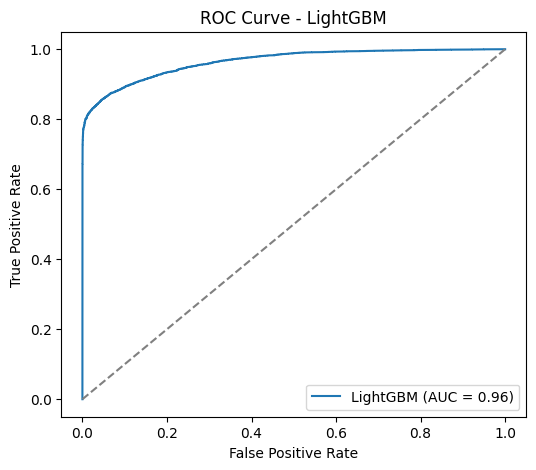

In [69]:
from sklearn.metrics import roc_curve, roc_auc_score

# probability prediction
y_prob_lgb = lgb_model.predict_proba(X_test)[:,1]

# calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lgb)

# calculate AUC score
auc_lgb = roc_auc_score(y_test, y_prob_lgb)

# plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="LightGBM (AUC = {:.2f})".format(auc_lgb))
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend()
plt.show()

In [70]:
import joblib
joblib.dump(lgb_model,"model.pkl")

['model.pkl']

In [71]:
import joblib
import numpy as np

# load model
model = joblib.load("model.pkl")

# feature variables 

pos = 90      # number of posts
flw = 45      # Followers Count
flg = 8       # Following Count

bl = 4        # bio length (number of characters)
pic = 1       # profile picture (0 = no, 1 = yes)
lin = 0       # external link (0 = no, 1 = yes)

cl = 0        # average caption length (characters)
cz = 0        # caption zero percentage (0.0 to 1.0)
ni = 0        # non-image percentage (0.0 to 1.0)

erl = 0       # engagement rate (likes) -  ER(likes) = Total Likes / (Posts × Followers)
erc = 0       # engagement rate (comments)  -  ER(Comments) = Total Comments / (Posts × Followers)

lt = 0.78     # location tag percentage (0.0 to 1.0)
hc = 5        # average hashtag count (number of hashtags per post)
pr = 0.58     # promotional keywords usage (0.0 to 1.0)

cs = 0.56     # content similarity (0.0 to 1.0)
pi = 24       # post interval (in hours)


features = np.array([[pos, flw, flg, bl, pic, lin, cl, cz, ni, erl, erc, lt, hc, pr, cs, pi]])


prediction = model.predict(features)

if prediction[0] == 1:
    print("Fake Instagram Account")
else:
    print("Real Instagram Account")

Fake Instagram Account


c:\Users\anujg\anaconda3\envs\IG\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
